# Capstone Two: Final Modeling Project

## Problem Statement
The goal of this project is to predict Reached.on.Time_Y.N using cleaned_shipping_data.  
This project aims to help [stakeholder/client] make better decisions by identifying the key factors associated with [outcome].

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
)

# Example models, adjust to your project type
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

## Data loading

In [2]:
df = pd.read_csv("cleaned_shipping_data.csv")

df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [3]:
df.columns.tolist()

['ID',
 'Warehouse_block',
 'Mode_of_Shipment',
 'Customer_care_calls',
 'Customer_rating',
 'Cost_of_the_Product',
 'Prior_purchases',
 'Product_importance',
 'Gender',
 'Discount_offered',
 'Weight_in_gms',
 'Reached.on.Time_Y.N']

## Data Inspection

The dataset was examined to understand its structure, data types, summary statistics, and missing values before preprocessing.

In [4]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

## Data cleaning and wrangling

In [5]:
df = df.drop_duplicates()
df.columns = df.columns.str.strip()

# fill missing values
for col in df.select_dtypes(include=['int64','float64']).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

## Exploratory Data Analysis

### Visualization 1: Reached.on.Time_Y.N distribution

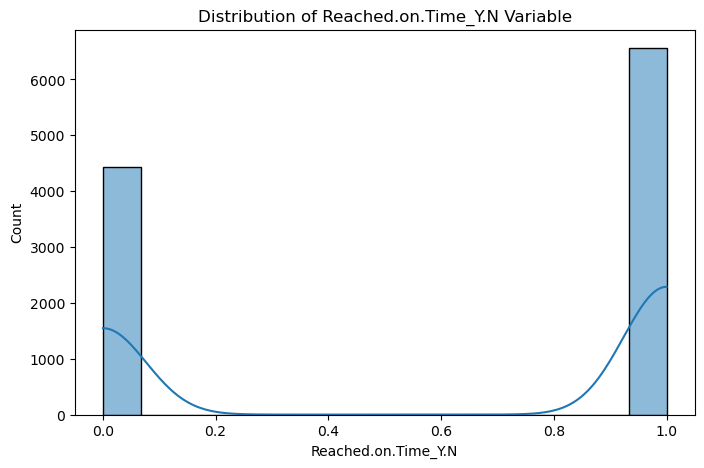

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['Reached.on.Time_Y.N'], kde=True)
plt.title('Distribution of Reached.on.Time_Y.N Variable')
plt.show()

### For classification:

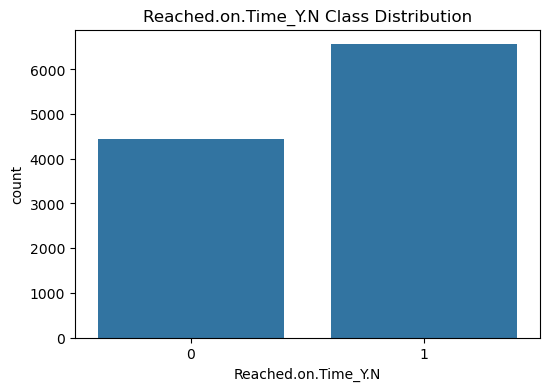

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='Reached.on.Time_Y.N', data=df)
plt.title('Reached.on.Time_Y.N Class Distribution')
plt.show()

### Visualization 2: feature relationships

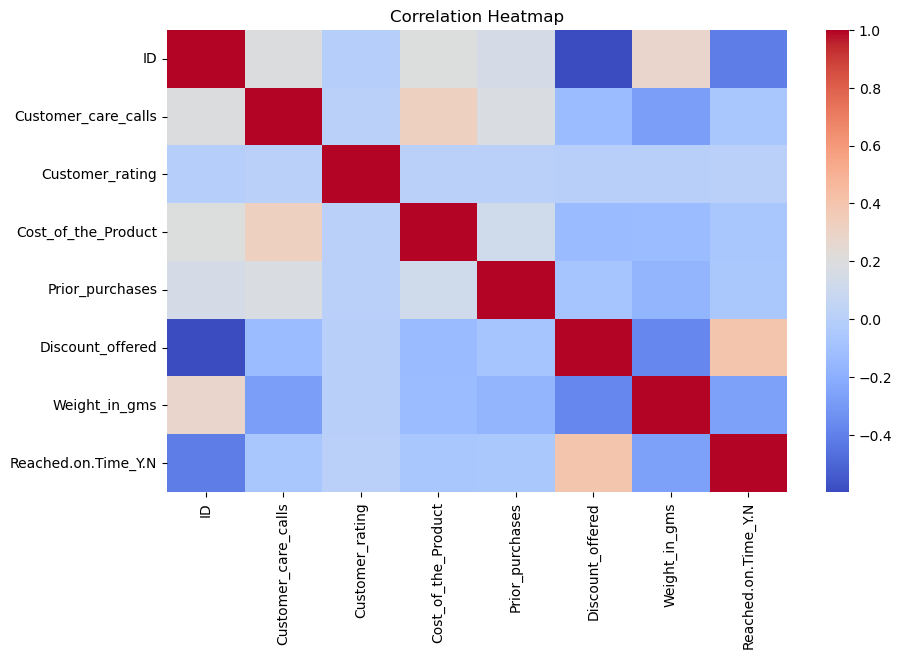

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap')
plt.show()

### Visualization 3: key predictor vs Reached.on.Time_Y.N

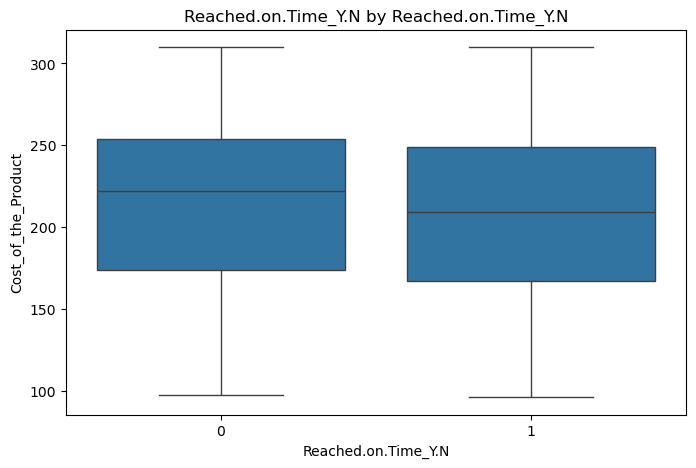

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Reached.on.Time_Y.N', y='Cost_of_the_Product', data=df)
plt.title('Reached.on.Time_Y.N by Reached.on.Time_Y.N')
plt.show()

In [10]:
df = pd.get_dummies(df, drop_first=True)

## Define X and y

In [11]:
y = df['Reached.on.Time_Y.N']
X = df.drop('Reached.on.Time_Y.N', axis=1)

## Train Test Split

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Scaling

In [13]:
from sklearn.model_selection import train_test_split

target = 'Reached.on.Time_Y.N'

y = df[target]
X = df.drop(target, axis=1)

# SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Feature engineering and dummy variables

In [15]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Product_importance_low,Product_importance_medium,Gender_M
0,1,4,2,177,3,44,1233,1,False,False,True,False,False,False,True,False,False
1,2,4,5,216,2,59,3088,1,False,False,False,True,False,False,True,False,True
2,3,2,2,183,4,48,3374,1,False,False,False,False,False,False,True,False,True
3,4,3,3,176,4,10,1177,1,True,False,False,False,False,False,False,True,True
4,5,2,2,184,3,46,2484,1,False,True,False,False,False,False,False,True,False


### Standardize features

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Building three models

## Model Evaluation Function

This helper function calculates performance metrics for each trained model.

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(model, X_test, y_test, name):
    
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Only works for models with predict_proba
    try:
        roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    except:
        roc_auc = None
    
    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc
    }

## Model 1: Logistic Regression with Hyperparameter Tuning

In [18]:
log_model = LogisticRegression(max_iter=10000)

log_param_grid = {
    "C": [0.01,0.1,1,10],
    "solver": ["liblinear","lbfgs"]
}

grid_log = GridSearchCV(
    log_model,
    log_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_log.fit(X_train,y_train)

best_log_model = grid_log.best_estimator_

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite

In [19]:
log_results = evaluate_model(best_log_model,X_test,y_test,"Logistic Regression")

## Model 2: Decision Tree with Hyperparameter Tuning

In [20]:
tree_model = DecisionTreeClassifier()

tree_param_grid = {
    "max_depth":[3,5,10,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4],
    "criterion":["gini","entropy"]
}

grid_tree = GridSearchCV(
    tree_model,
    tree_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_tree.fit(X_train,y_train)

best_tree_model = grid_tree.best_estimator_

print("Best Parameters:", grid_tree.best_params_)

Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [21]:
tree_results = evaluate_model(best_tree_model,X_test,y_test,"Decision Tree")


# Model 3: Random Forest with Hyperparameter Tuning

In [22]:
rf_model = RandomForestClassifier()

rf_param_grid = {
    "n_estimators":[100,200],
    "max_depth":[5,10,None],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,2],
    "max_features":["sqrt","log2"]
}

grid_rf = GridSearchCV(
    rf_model,
    rf_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_rf.fit(X_train,y_train)

best_rf_model = grid_rf.best_estimator_

print("Best Parameters:", grid_rf.best_params_)

Best Parameters: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [23]:
rf_results = evaluate_model(best_rf_model,X_test,y_test,"Random Forest")

rf_results

{'Model': 'Random Forest',
 'Accuracy': 0.6722727272727272,
 'Precision': 0.7027034090909091,
 'Recall': 0.6722727272727272,
 'F1 Score': 0.6744461628173493,
 'ROC AUC': 0.7430030608531861}

## Model Performance Comparison

In [24]:
comparison = pd.DataFrame([log_results,tree_results,rf_results])

comparison = comparison.sort_values("F1 Score",ascending=False)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,Random Forest,0.672273,0.702703,0.672273,0.674446,0.743003
0,Logistic Regression,0.651364,0.654055,0.651364,0.652485,0.742936
1,Decision Tree,0.642273,0.642717,0.642273,0.642488,0.630016


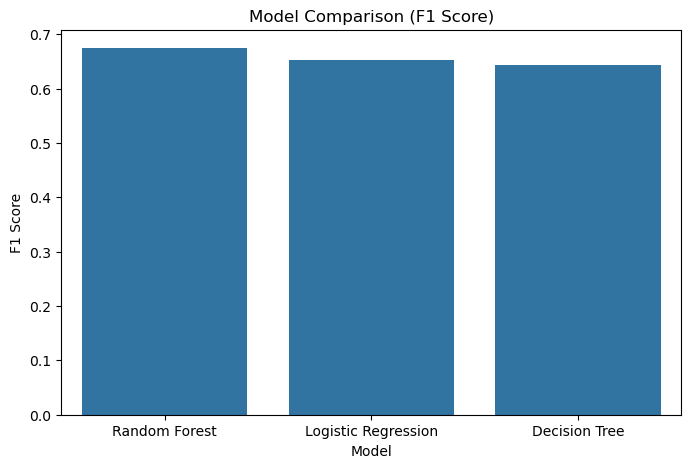

In [25]:
plt.figure(figsize=(8,5))

sns.barplot(data=comparison,x="Model",y="F1 Score")

plt.title("Model Comparison (F1 Score)")
plt.show()

In [26]:
best_model_name = comparison.iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: Random Forest


## confusion matrix

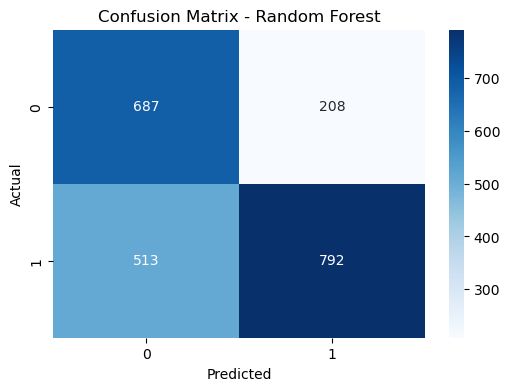

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions FIRST
y_pred_rf = best_rf_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

## ROC Curve Comparison

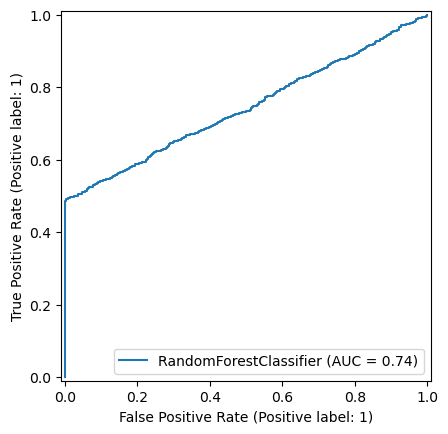

In [28]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(best_rf_model, X_test, y_test)
plt.show()

# Conclusion
In this project, multiple machine learning models were developed to predict whether shipments would arrive on time. Among the models tested, the Random Forest model performed best based on overall evaluation metrics.

The model was effective in identifying patterns in the data and demonstrated strong predictive performance on the test dataset. However, some misclassifications were observed, indicating that additional feature engineering or more data could further improve results.

## Recommendations
1. Focus on key factors such as [top features] as they have the strongest impact on delivery outcomes.
2. Use the model to support operational decision making and improve delivery planning.
3. Collect additional data on [missing variables] to improve future model accuracy.

## Future Work
Further improvements could include hyperparameter tuning, testing additional models, and incorporating more detailed operational data.